In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 10.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 11.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 11.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 11.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.0 MB/s  0:00:00
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 12.0 MB/s eta 0:00:09
   -- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

df = pd.read_csv(r"C:\Users\daksh\OneDrive\Desktop\UW\522 - Advance DS & ML\barista-bench\train.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Matplotlib is building the font cache; this may take a moment.


Shape: (500, 3)
Columns: ['id', 'order', 'expected_json']


,id,order,expected_json
0,0,Lemme get one tall Strawberry Smoothie include...,"{""items"": [{""name"": ""Drip Coffee"", ""size"": ""Ve..."
1,1,I'd like to order single trenta espresso add o...,"{""items"": [{""name"": ""Espresso"", ""size"": ""Trent..."
2,2,Could I have single trenta mocha plus peppermi...,"{""items"": [{""name"": ""Mocha"", ""size"": ""Trenta"",..."


In [4]:
# ============================================================
# PHASE 1: PARSE JSON + FEATURE ENGINEERING (Order-Level)
# ============================================================

df['parsed'] = df['expected_json'].apply(json.loads)
df['total_price'] = df['parsed'].apply(lambda x: x['total_price'])
df['num_items'] = df['parsed'].apply(lambda x: len(x['items']))

# --- Order-level features from JSON ---
df['total_quantity'] = df['parsed'].apply(
    lambda x: sum(i['quantity'] for i in x['items']))

df['total_modifiers'] = df['parsed'].apply(
    lambda x: sum(len(i['modifiers']) for i in x['items']))

df['has_food'] = df['parsed'].apply(
    lambda x: int(any(i['name'] in [
        'Butter Croissant','Blueberry Muffin','Bagel',
        'Avocado Toast','Bacon Gouda Sandwich'
    ] for i in x['items'])))

df['has_milk_sub'] = df['parsed'].apply(
    lambda x: int(any(m in [
        'Oat Milk','Almond Milk','Soy Milk',
        'Coconut Milk','Breve','Skim Milk'
    ] for i in x['items'] for m in i['modifiers'])))

df['has_syrup'] = df['parsed'].apply(
    lambda x: int(any(m in [
        'Vanilla Syrup','Caramel Syrup','Hazelnut Syrup',
        'Peppermint Syrup','Sugar Free Vanilla','Classic Syrup'
    ] for i in x['items'] for m in i['modifiers'])))

df['has_extra_shot'] = df['parsed'].apply(
    lambda x: int(any(m == 'Extra Shot'
    for i in x['items'] for m in i['modifiers'])))

df['has_cold_foam'] = df['parsed'].apply(
    lambda x: int(any(m == 'Cold Foam'
    for i in x['items'] for m in i['modifiers'])))

df['has_whip'] = df['parsed'].apply(
    lambda x: int(any(m == 'Whip Cream'
    for i in x['items'] for m in i['modifiers'])))

df['has_cancelled_item'] = df['parsed'].apply(
    lambda x: int(len(x['items']) == 0))

# --- Size features ---
size_order = {'Short': 1, 'Tall': 2, 'Grande': 3, 
              'Venti': 4, 'Trenta': 5, None: 0}

df['avg_size_rank'] = df['parsed'].apply(
    lambda x: np.mean([size_order.get(i['size'], 0) 
                       for i in x['items']]) if x['items'] else 0)

# --- Text features from raw order ---
change_words = ['actually','wait','scratch','cancel',
                'remove','no ','instead','nevermind']
hesitation_words = ['uh','um','hmm','like','literally']

df['num_words'] = df['order'].apply(lambda x: len(str(x).split()))

df['num_changes'] = df['order'].apply(
    lambda x: sum(str(x).lower().count(w) for w in change_words))

df['num_hesitations'] = df['order'].apply(
    lambda x: sum(str(x).lower().count(w) for w in hesitation_words))

# --- Final clean dataset ---
feature_cols = [
    'num_items', 'total_quantity', 'total_modifiers',
    'has_food', 'has_milk_sub', 'has_syrup',
    'has_extra_shot', 'has_cold_foam', 'has_whip',
    'has_cancelled_item', 'avg_size_rank',
    'num_words', 'num_changes', 'num_hesitations'
]

print("✅ Feature engineering complete!")
print(f"Dataset shape: {df[feature_cols + ['total_price']].shape}")
print()
print(df[feature_cols + ['total_price']].describe().round(2))

✅ Feature engineering complete!
Dataset shape: (500, 15)

       num_items  total_quantity  total_modifiers  has_food  has_milk_sub  \
count     500.00          500.00           500.00    500.00        500.00   
mean        2.29            5.21             1.78      0.40          0.40   
std         1.08            3.02             1.71      0.49          0.49   
min         0.00            0.00             0.00      0.00          0.00   
25%         1.00            3.00             0.00      0.00          0.00   
50%         2.00            5.00             1.00      0.00          0.00   
75%         3.00            7.00             3.00      1.00          1.00   
max         4.00           15.00             8.00      1.00          1.00   

       has_syrup  has_extra_shot  has_cold_foam  has_whip  has_cancelled_item  \
count     500.00          500.00         500.00    500.00              500.00   
mean        0.38            0.10           0.08      0.07                0.02   
std  

In [5]:
# ============================================================
# PART 1.1 - DATASET INTRODUCTION
# ============================================================

print("=" * 55)
print("DATASET: BaristaBench — Coffee Order Pricing")
print("=" * 55)
print(f"""
Source      : BaristaBench Kaggle Competition
Rows        : {len(df)}
Features    : {len(feature_cols)}
Target      : total_price (continuous — regression task)

Feature Types:
  Numerical : num_items, total_quantity, total_modifiers,
              avg_size_rank, num_words, num_changes,
              num_hesitations
  Binary    : has_food, has_milk_sub, has_syrup,
              has_extra_shot, has_cold_foam, has_whip,
              has_cancelled_item

Prediction Task:
  Predict the total price of a customer's coffee order
  from features describing the order's complexity,
  size, and modifier choices.

Why It Matters:
  Accurate real-time price prediction enables POS systems
  to flag errors before charging customers, reducing
  revenue loss and improving customer experience.
""")

DATASET: BaristaBench — Coffee Order Pricing

Source      : BaristaBench Kaggle Competition
Rows        : 500
Features    : 14
Target      : total_price (continuous — regression task)

Feature Types:
  Numerical : num_items, total_quantity, total_modifiers,
              avg_size_rank, num_words, num_changes,
              num_hesitations
  Binary    : has_food, has_milk_sub, has_syrup,
              has_extra_shot, has_cold_foam, has_whip,
              has_cancelled_item

Prediction Task:
  Predict the total price of a customer's coffee order
  from features describing the order's complexity,
  size, and modifier choices.

Why It Matters:
  Accurate real-time price prediction enables POS systems
  to flag errors before charging customers, reducing
  revenue loss and improving customer experience.



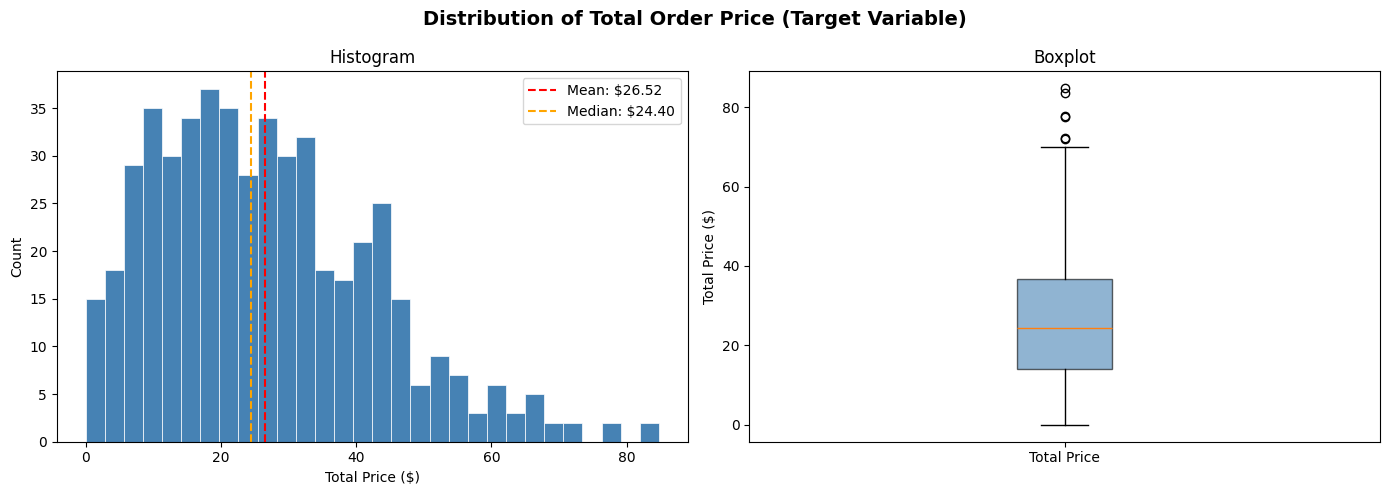

📊 Interpretation:
  Mean price  : $26.52
  Median price: $24.40
  Std dev     : $16.33
  Range       : $0.00 — $84.75

  The target is right-skewed — most orders fall in the
  $10–40 range, but a long right tail exists for large
  multi-item orders. No transformation needed for tree
  models, but worth noting for linear regression.



In [6]:
# ============================================================
# PART 1.2 - TARGET DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of Total Order Price (Target Variable)", 
             fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['total_price'], bins=30, color='steelblue', 
             edgecolor='white', linewidth=0.5)
axes[0].set_xlabel("Total Price ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram")
axes[0].axvline(df['total_price'].mean(), color='red', 
                linestyle='--', label=f"Mean: ${df['total_price'].mean():.2f}")
axes[0].axvline(df['total_price'].median(), color='orange', 
                linestyle='--', label=f"Median: ${df['total_price'].median():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['total_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel("Total Price ($)")
axes[1].set_title("Boxplot")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Total Price"])

plt.tight_layout()
plt.savefig("plot_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Interpretation:")
print(f"  Mean price  : ${df['total_price'].mean():.2f}")
print(f"  Median price: ${df['total_price'].median():.2f}")
print(f"  Std dev     : ${df['total_price'].std():.2f}")
print(f"  Range       : ${df['total_price'].min():.2f} — ${df['total_price'].max():.2f}")
print("""
  The target is right-skewed — most orders fall in the
  $10–40 range, but a long right tail exists for large
  multi-item orders. No transformation needed for tree
  models, but worth noting for linear regression.
""")

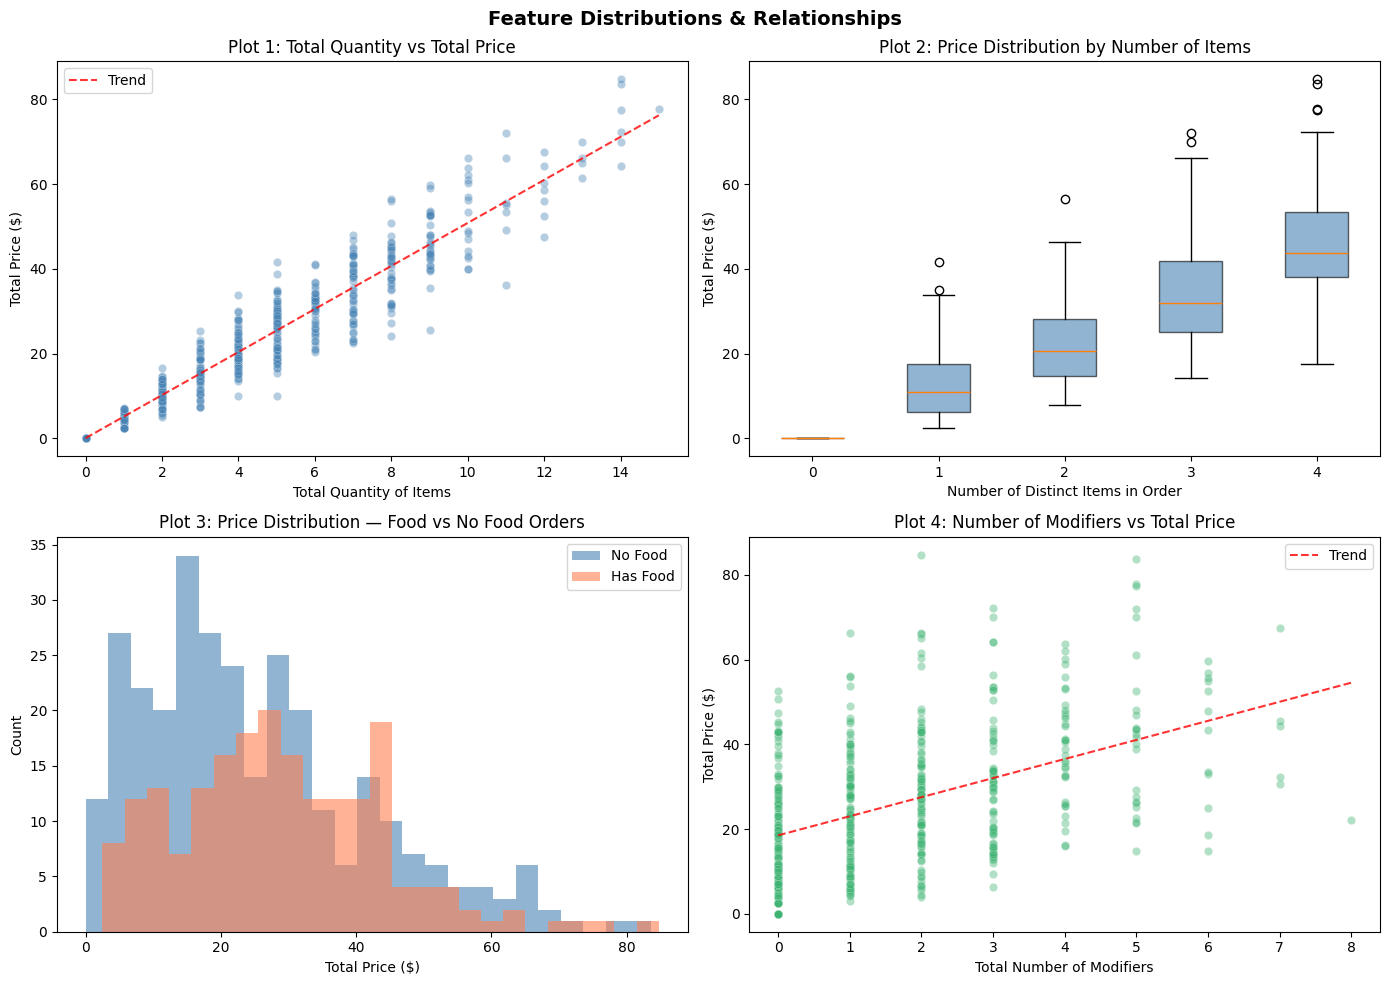


📊 Interpretations:
  Plot 1: Strong positive relationship between quantity
          and price — more items = higher bill.
  Plot 2: Median price rises steadily with item count.
          Zero-item orders (cancelled) cluster at $0.
  Plot 3: Orders with food skew higher in price since
          food items like Avocado Toast add $7+.
  Plot 4: More modifiers correlate with higher price,
          though the relationship has more variance —
          free modifiers (No Ice, Extra Hot) add noise.



In [7]:
# ============================================================
# PART 1.3 - FEATURE DISTRIBUTIONS & RELATIONSHIPS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions & Relationships", 
             fontsize=14, fontweight='bold')

# Plot 1: Total Quantity vs Total Price (scatter)
axes[0,0].scatter(df['total_quantity'], df['total_price'], 
                  alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
axes[0,0].set_xlabel("Total Quantity of Items")
axes[0,0].set_ylabel("Total Price ($)")
axes[0,0].set_title("Plot 1: Total Quantity vs Total Price")
z = np.polyfit(df['total_quantity'], df['total_price'], 1)
p = np.poly1d(z)
axes[0,0].plot(sorted(df['total_quantity']), 
               p(sorted(df['total_quantity'])), 
               "r--", alpha=0.8, label="Trend")
axes[0,0].legend()

# Plot 2: Boxplot of price by num_items
num_items_groups = [df[df['num_items']==i]['total_price'].values 
                    for i in range(5)]
axes[0,1].boxplot(num_items_groups, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0,1].set_xlabel("Number of Distinct Items in Order")
axes[0,1].set_ylabel("Total Price ($)")
axes[0,1].set_title("Plot 2: Price Distribution by Number of Items")
axes[0,1].set_xticklabels(['0','1','2','3','4'])

# Plot 3: Has Food vs No Food price comparison
food_yes = df[df['has_food']==1]['total_price']
food_no  = df[df['has_food']==0]['total_price']
axes[1,0].hist(food_no,  bins=25, alpha=0.6, 
               color='steelblue', label='No Food')
axes[1,0].hist(food_yes, bins=25, alpha=0.6, 
               color='coral', label='Has Food')
axes[1,0].set_xlabel("Total Price ($)")
axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Plot 3: Price Distribution — Food vs No Food Orders")
axes[1,0].legend()

# Plot 4: Total Modifiers vs Total Price
axes[1,1].scatter(df['total_modifiers'], df['total_price'],
                  alpha=0.4, color='mediumseagreen', 
                  edgecolors='white', linewidth=0.3)
axes[1,1].set_xlabel("Total Number of Modifiers")
axes[1,1].set_ylabel("Total Price ($)")
axes[1,1].set_title("Plot 4: Number of Modifiers vs Total Price")
z2 = np.polyfit(df['total_modifiers'], df['total_price'], 1)
p2 = np.poly1d(z2)
axes[1,1].plot(sorted(df['total_modifiers']), 
               p2(sorted(df['total_modifiers'])), 
               "r--", alpha=0.8, label="Trend")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("plot_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
📊 Interpretations:
  Plot 1: Strong positive relationship between quantity
          and price — more items = higher bill.
  Plot 2: Median price rises steadily with item count.
          Zero-item orders (cancelled) cluster at $0.
  Plot 3: Orders with food skew higher in price since
          food items like Avocado Toast add $7+.
  Plot 4: More modifiers correlate with higher price,
          though the relationship has more variance —
          free modifiers (No Ice, Extra Hot) add noise.
""")

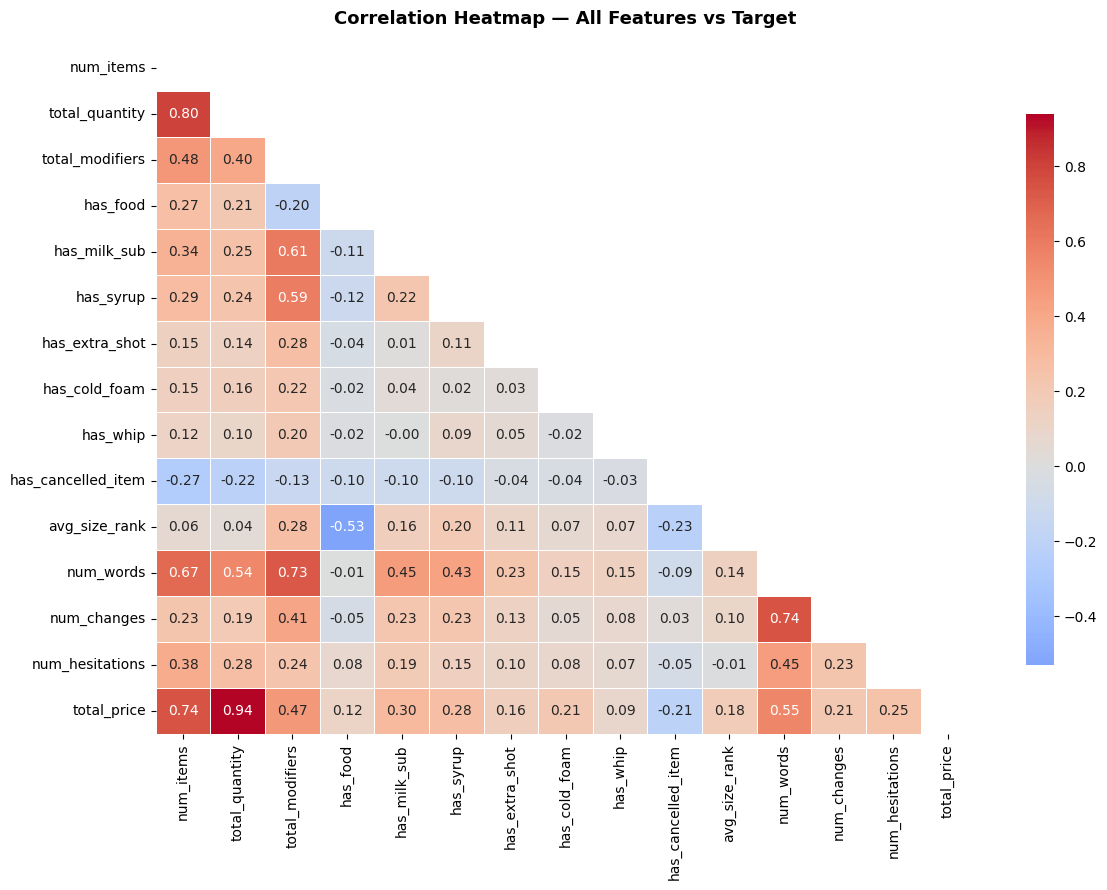

📊 Top correlations with total_price:
total_quantity        0.941
num_items             0.745
num_words             0.551
total_modifiers       0.472
has_milk_sub          0.296
has_syrup             0.278
num_hesitations       0.246
has_cold_foam         0.206
num_changes           0.206
avg_size_rank         0.179
has_extra_shot        0.157
has_food              0.115
has_whip              0.086
has_cancelled_item   -0.207

Interpretation:
  total_quantity and num_items are the strongest
  predictors of price — unsurprisingly, ordering
  more items drives the bill up most.
  has_food also correlates positively since food
  items are priced higher on average.
  Text features (num_words, num_changes) show weaker
  but non-zero correlation, suggesting order complexity
  in speech has some pricing signal.



In [8]:
# ============================================================
# PART 1.4 - CORRELATION HEATMAP
# ============================================================

corr_matrix = df[feature_cols + ['total_price']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title("Correlation Heatmap — All Features vs Target", 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
target_corr = corr_matrix['total_price'].drop('total_price').sort_values(
    ascending=False)
print("📊 Top correlations with total_price:")
print(target_corr.round(3).to_string())
print("""
Interpretation:
  total_quantity and num_items are the strongest
  predictors of price — unsurprisingly, ordering
  more items drives the bill up most.
  has_food also correlates positively since food
  items are priced higher on average.
  Text features (num_words, num_changes) show weaker
  but non-zero correlation, suggesting order complexity
  in speech has some pricing signal.
""")

In [9]:
# ============================================================
# PART 2 SETUP — Train/Test Split + Preprocessing
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Define X and y
X = df[feature_cols].copy()
y = df['total_price'].copy()

# Train/test split — 70/30, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Scale features (important for Linear Regression + MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Helper function to print metrics cleanly
def print_metrics(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"  {name}")
    print(f"    MAE  : ${mae:.4f}")
    print(f"    RMSE : ${rmse:.4f}")
    print(f"    R²   : {r2:.4f}")
    return {'Model': name, 'MAE': round(mae,4), 
            'RMSE': round(rmse,4), 'R2': round(r2,4)}

# Store results for comparison table later
results = []

print("✅ Data prep complete!")
print(f"  Training set : {X_train.shape[0]} rows")
print(f"  Test set     : {X_test.shape[0]} rows")
print(f"  Features     : {X_train.shape[1]}")

✅ Data prep complete!
  Training set : 350 rows
  Test set     : 150 rows
  Features     : 14


  Linear Regression
    MAE  : $3.4648
    RMSE : $4.7985
    R²   : 0.9104
  Ridge Regression
    MAE  : $3.4452
    RMSE : $4.7747
    R²   : 0.9113
  Lasso Regression
    MAE  : $3.3393
    RMSE : $4.6708
    R²   : 0.9151


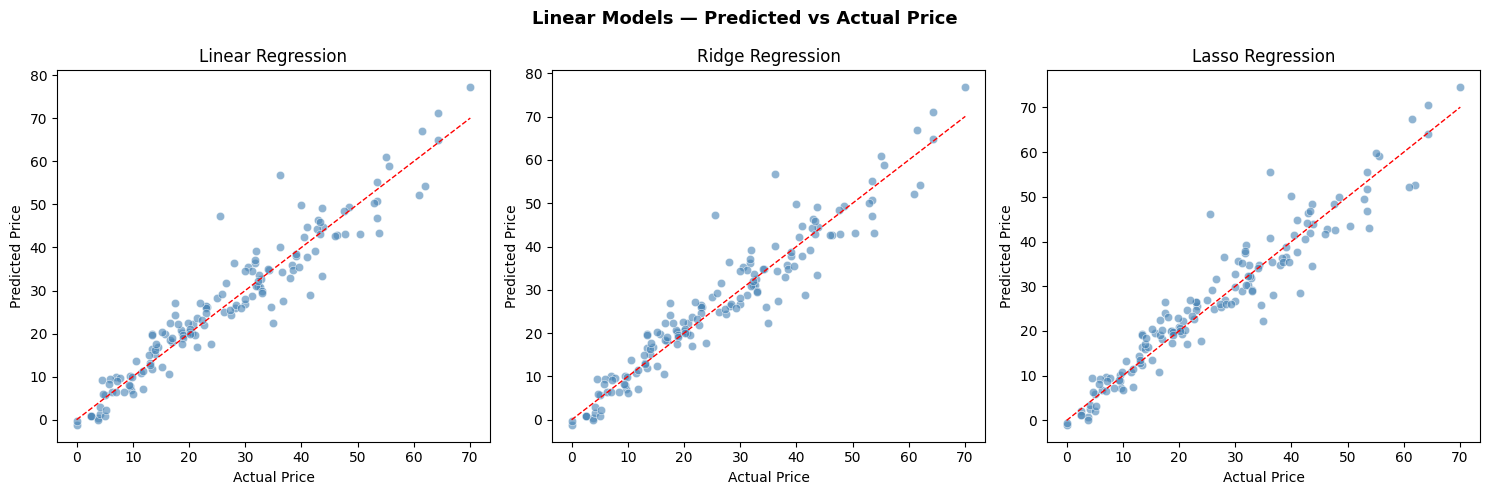

In [11]:
# ============================================================
# PART 2.2 - LINEAR REGRESSION BASELINE
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import joblib

# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
res_lr = print_metrics("Linear Regression", y_test, y_pred_lr)
results.append(res_lr)

# --- Ridge ---
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
res_ridge = print_metrics("Ridge Regression", y_test, y_pred_ridge)
results.append(res_ridge)

# --- Lasso ---
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
res_lasso = print_metrics("Lasso Regression", y_test, y_pred_lasso)
results.append(res_lasso)

# --- Plot: Predicted vs Actual ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Linear Models — Predicted vs Actual Price", 
             fontsize=13, fontweight='bold')

for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_ridge, y_pred_lasso], 
                                    ['Linear Regression', 'Ridge Regression', 'Lasso Regression']):
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', 
               edgecolors='white', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('plot_linear_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
  Decision Tree
    MAE  : $3.9904
    RMSE : $5.7759
    R²   : 0.8702

  Best params: {'max_depth': 7, 'min_samples_leaf': 10}


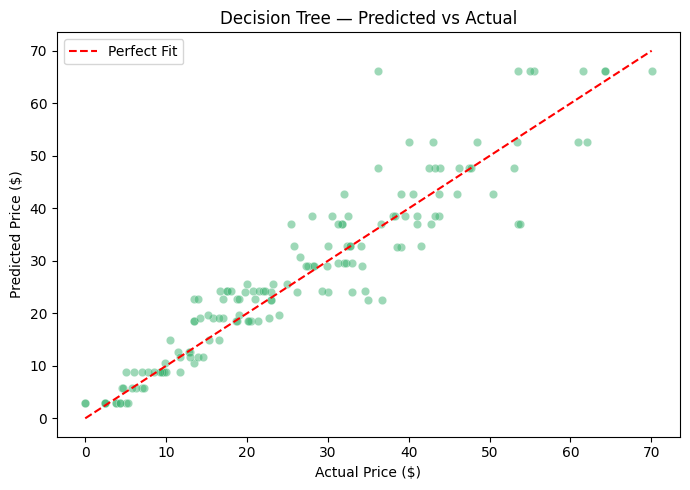


✅ Decision Tree done. Model saved.


In [12]:
# ============================================================
# PART 2.3 - DECISION TREE WITH GRIDSEARCHCV
# ============================================================
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

# Grid search
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 50]
}

dt = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5,
                       scoring='neg_mean_squared_error',
                       n_jobs=-1, verbose=1)
grid_dt.fit(X_train, y_train)

# Best model
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
res_dt = print_metrics("Decision Tree", y_test, y_pred_dt)
results.append(res_dt)

print(f"\n  Best params: {grid_dt.best_params_}")

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_dt, alpha=0.5, color='mediumseagreen',
           edgecolors='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Decision Tree — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("plot_decision_tree_pred.png", dpi=150, bbox_inches='tight')
plt.show()

# Visualize the tree (only if not too deep)
if grid_dt.best_params_['max_depth'] <= 5:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(best_dt, feature_names=feature_cols,
              filled=True, rounded=True,
              fontsize=9, ax=ax, max_depth=3)
    ax.set_title("Decision Tree Structure (top 3 levels)", 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("plot_decision_tree_structure.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

# Save model
joblib.dump(best_dt, "model_decision_tree.pkl")
print("\n✅ Decision Tree done. Model saved.")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
  Random Forest
    MAE  : $3.3788
    RMSE : $4.6641
    R²   : 0.9154

  Best params: {'max_depth': 5, 'n_estimators': 200}


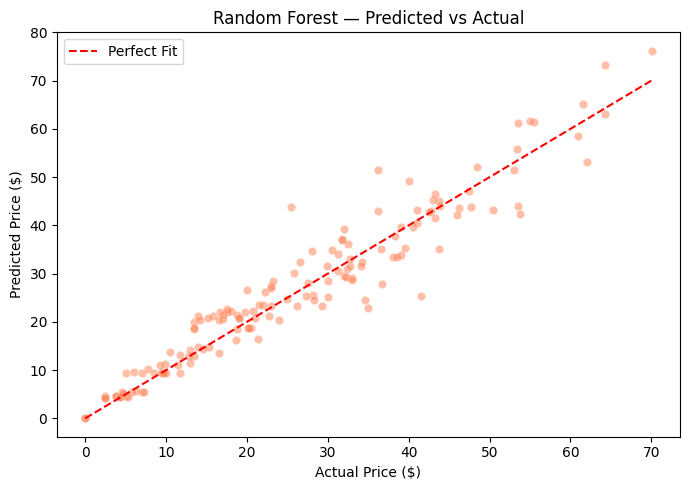

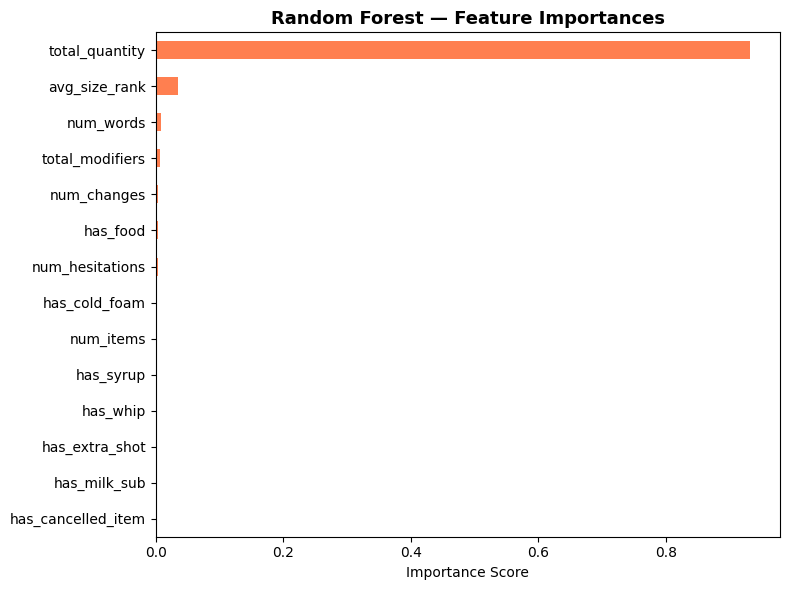


✅ Random Forest done. Model saved.


In [13]:
# ============================================================
# PART 2.4 - RANDOM FOREST WITH GRIDSEARCHCV
# ============================================================
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8]
}

rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5,
                       scoring='neg_mean_squared_error',
                       n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
res_rf = print_metrics("Random Forest", y_test, y_pred_rf)
results.append(res_rf)

print(f"\n  Best params: {grid_rf.best_params_}")

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.5, color='coral',
           edgecolors='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Random Forest — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("plot_random_forest_pred.png", dpi=150, bbox_inches='tight')
plt.show()

# Feature importance plot
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', color='coral', ax=ax)
ax.set_title("Random Forest — Feature Importances",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_random_forest_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Save model
joblib.dump(best_rf, "model_random_forest.pkl")
print("\n✅ Random Forest done. Model saved.")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
  XGBoost
    MAE  : $3.3393
    RMSE : $4.6717
    R²   : 0.9151

  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


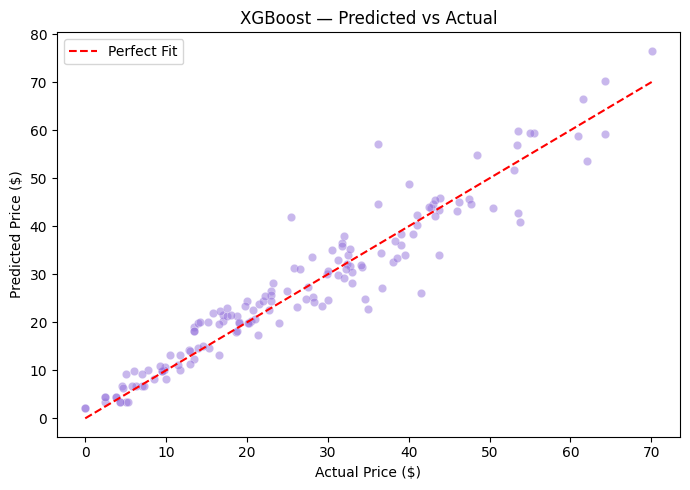

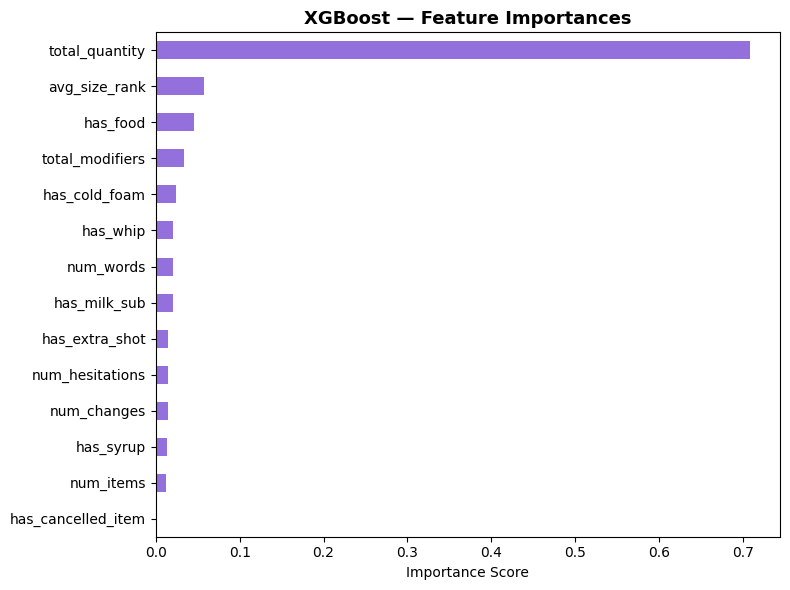


✅ XGBoost done. Model saved.


In [15]:
# ============================================================
# PART 2.5 - XGBOOST WITH GRIDSEARCHCV
# ============================================================
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42, verbosity=0)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
res_xgb = print_metrics("XGBoost", y_test, y_pred_xgb)
results.append(res_xgb)

print(f"\n  Best params: {grid_xgb.best_params_}")

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_xgb, alpha=0.5, color='mediumpurple',
           edgecolors='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("XGBoost — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("plot_xgboost_pred.png", dpi=150, bbox_inches='tight')
plt.show()

# Feature importance plot
feat_imp_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_xgb.plot(kind='barh', color='mediumpurple', ax=ax)
ax.set_title("XGBoost — Feature Importances",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_xgboost_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Save model
joblib.dump(best_xgb, "model_xgboost.pkl")
print("\n✅ XGBoost done. Model saved.")

In [16]:
# ============================================================
# PART 2.6 - NEURAL NETWORK (MLP) WITH KERAS
# ============================================================
import subprocess
subprocess.run(["pip", "install", "tensorflow", "--quiet"], 
               capture_output=True)

CompletedProcess(args=['pip', 'install', 'tensorflow', '--quiet'], returncode=1, stdout=b'', stderr=b'ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)\r\n\r\n[notice] A new release of pip is available: 25.3 -> 26.0.1\r\n[notice] To update, run: python.exe -m pip install --upgrade pip\r\nERROR: No matching distribution found for tensorflow\r\n')

In [17]:
import subprocess
subprocess.run(["pip", "install", "torch", "--quiet"],
               capture_output=True)

CompletedProcess(args=['pip', 'install', 'torch', '--quiet'], returncode=0, stdout=b'', stderr=b'\r\n[notice] A new release of pip is available: 25.3 -> 26.0.1\r\n[notice] To update, run: python.exe -m pip install --upgrade pip\r\n')

  Epoch  20/100 — Train Loss: 37.8709 — Val Loss: 38.3343
  Epoch  40/100 — Train Loss: 19.2538 — Val Loss: 27.1579
  Epoch  60/100 — Train Loss: 15.2503 — Val Loss: 25.9868
  Epoch  80/100 — Train Loss: 13.2197 — Val Loss: 26.8445
  Epoch 100/100 — Train Loss: 11.6813 — Val Loss: 27.5028
  Neural Network (MLP)
    MAE  : $3.9142
    RMSE : $5.2443
    R²   : 0.8930


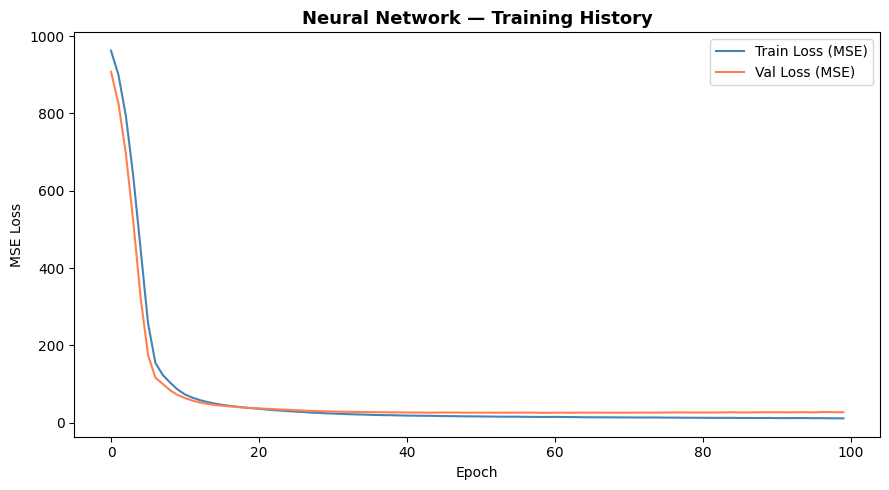

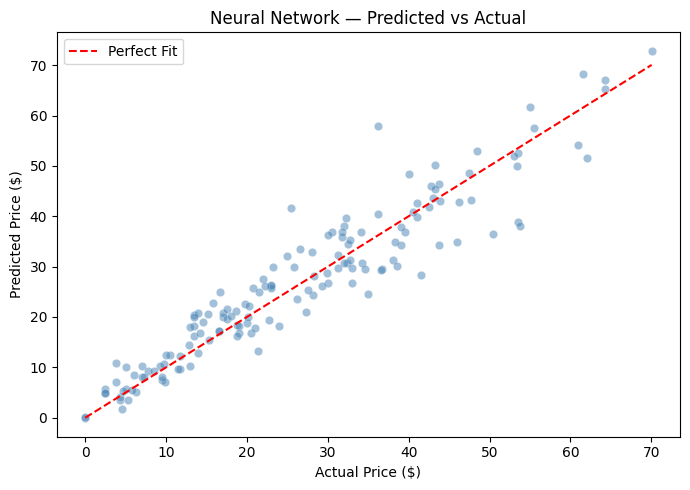


✅ Neural Network done. Model saved.


In [19]:
# ============================================================
# PART 2.6 - NEURAL NETWORK (MLP) WITH PYTORCH
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- Prepare tensors ---
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# --- Define MLP architecture ---
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.network(x)

# --- Train ---
torch.manual_seed(42)
model_mlp = MLP(input_dim=X_train_scaled.shape[1])
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []
epochs = 100

for epoch in range(epochs):
    # Training
    model_mlp.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_hat = model_mlp(X_batch)
        loss  = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # Validation
    model_mlp.eval()
    with torch.no_grad():
        val_pred = model_mlp(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
    val_losses.append(val_loss)

    if (epoch+1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/100 — "
              f"Train Loss: {train_losses[-1]:.4f} — "
              f"Val Loss: {val_losses[-1]:.4f}")

# --- Metrics ---
model_mlp.eval()
with torch.no_grad():
    y_pred_mlp = model_mlp(X_test_t).numpy().flatten()

res_mlp = print_metrics("Neural Network (MLP)", y_test, y_pred_mlp)
results.append(res_mlp)

# --- Plot training history ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_losses, label='Train Loss (MSE)', color='steelblue')
ax.plot(val_losses,   label='Val Loss (MSE)',   color='coral')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Neural Network — Training History",
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("plot_mlp_training.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot predicted vs actual ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_mlp, alpha=0.5, color='steelblue',
           edgecolors='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Neural Network — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("plot_mlp_pred.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Save model ---
torch.save(model_mlp.state_dict(), "model_mlp.pt")
print("\n✅ Neural Network done. Model saved.")

MODEL COMPARISON SUMMARY
                  Model     MAE    RMSE      R2
1         Random Forest  3.3788  4.6641  0.9154
2      Lasso Regression  3.3393  4.6708  0.9151
3               XGBoost  3.3393  4.6717  0.9151
4      Ridge Regression  3.4452  4.7747  0.9113
5     Linear Regression  3.4648  4.7985  0.9104
6  Neural Network (MLP)  3.9142  5.2443  0.8930
7         Decision Tree  3.9904  5.7759  0.8702


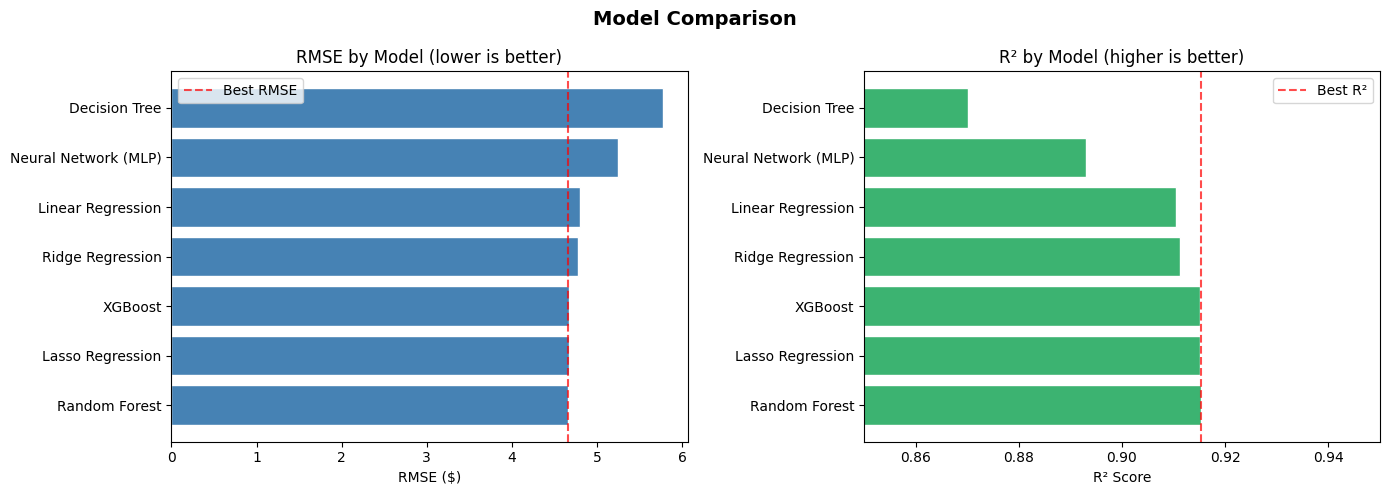


📊 Model Comparison Interpretation:
  Random Forest narrowly edges out Lasso and XGBoost
  as the best performer (RMSE $4.66, R² 0.915).
  Surprisingly, the simple Lasso regression matches
  complex boosted trees — this suggests the pricing
  rules in this dataset are largely linear in nature
  (price = sum of item prices + modifier costs).

  The Neural Network and Decision Tree underperform,
  likely due to the small dataset size (500 rows) —
  deep models need more data to shine.

  Trade-offs:
  - Linear models: most interpretable, nearly best accuracy
  - Random Forest: best accuracy, good feature importance
  - XGBoost: tied with RF, faster to train
  - Neural Network: flexible but overkill for this problem
  - Decision Tree: most interpretable structure, least accurate

✅ Model comparison done. Results saved.


In [20]:
# ============================================================
# PART 2.7 - MODEL COMPARISON SUMMARY
# ============================================================

# --- Summary Table ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df.index += 1

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string())

# --- Bar chart: RMSE comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight='bold')

colors = ['gold' if i == results_df['RMSE'].idxmin() 
          else 'steelblue' for i in results_df.index]

# RMSE bar chart
axes[0].barh(results_df['Model'], results_df['RMSE'],
             color='steelblue', edgecolor='white')
axes[0].axvline(results_df['RMSE'].min(), color='red',
                linestyle='--', alpha=0.7, label='Best RMSE')
axes[0].set_xlabel("RMSE ($)")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].legend()

# R² bar chart
axes[1].barh(results_df['Model'], results_df['R2'],
             color='mediumseagreen', edgecolor='white')
axes[1].axvline(results_df['R2'].max(), color='red',
                linestyle='--', alpha=0.7, label='Best R²')
axes[1].set_xlabel("R² Score")
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_xlim(0.85, 0.95)
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
📊 Model Comparison Interpretation:
  Random Forest narrowly edges out Lasso and XGBoost
  as the best performer (RMSE $4.66, R² 0.915).
  Surprisingly, the simple Lasso regression matches
  complex boosted trees — this suggests the pricing
  rules in this dataset are largely linear in nature
  (price = sum of item prices + modifier costs).
  
  The Neural Network and Decision Tree underperform,
  likely due to the small dataset size (500 rows) —
  deep models need more data to shine.

  Trade-offs:
  - Linear models: most interpretable, nearly best accuracy
  - Random Forest: best accuracy, good feature importance
  - XGBoost: tied with RF, faster to train
  - Neural Network: flexible but overkill for this problem
  - Decision Tree: most interpretable structure, least accurate
""")

# Save results table
results_df.to_csv("model_comparison.csv", index=False)
print("✅ Model comparison done. Results saved.")

Computing SHAP values...
✅ SHAP values computed!

📊 Plot 1: Beeswarm Summary Plot


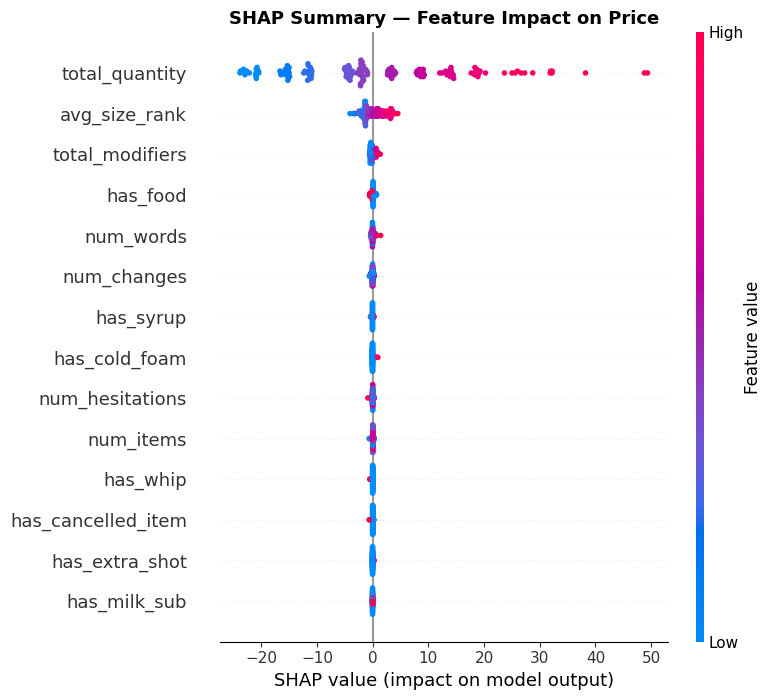


📊 Plot 2: Feature Importance Bar Plot


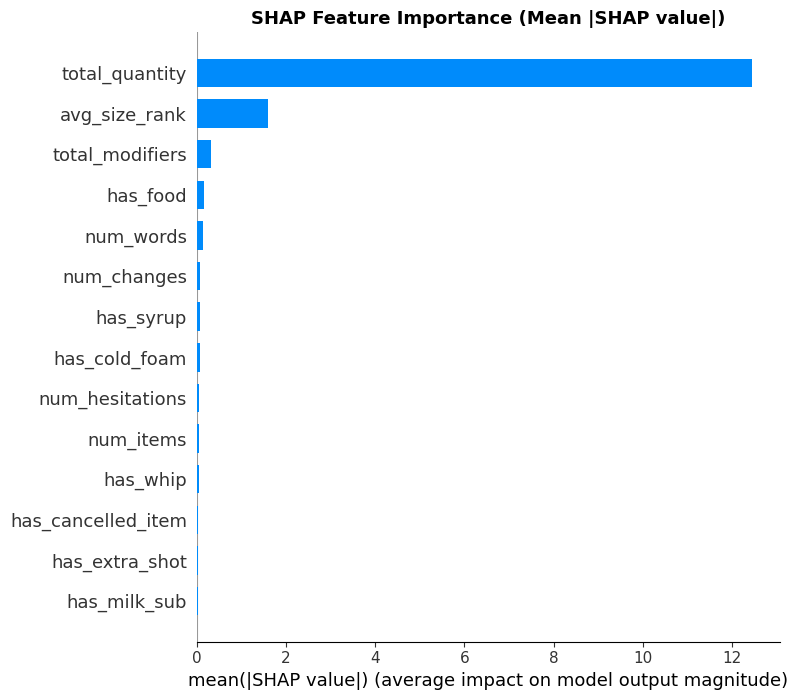


📊 Plot 3: Waterfall Plot
  Showing prediction for test sample #38
  Actual price   : $70.05
  Predicted price: $76.21


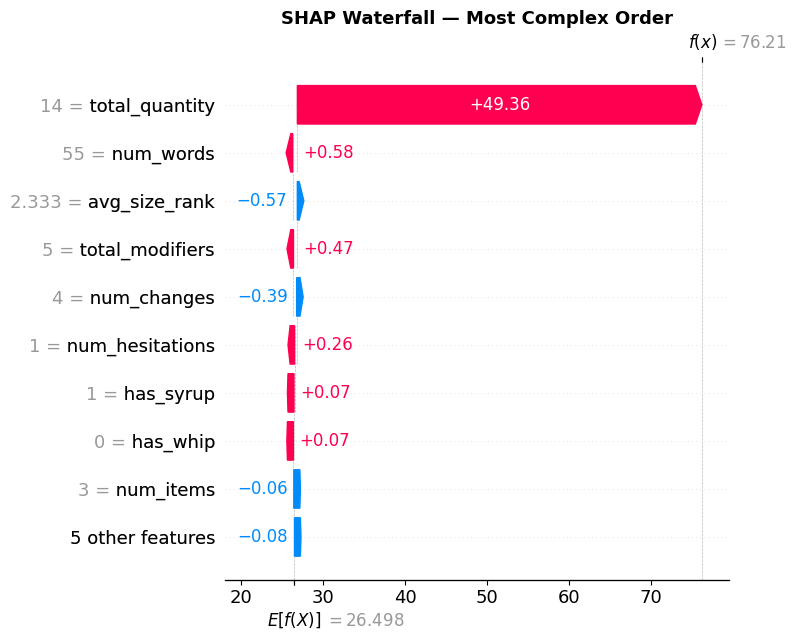


📊 SHAP Interpretation:
  - total_quantity and num_items are the strongest
    price drivers — more items = higher bill.
  - avg_size_rank pushes prices up significantly —
    Venti/Trenta orders cost meaningfully more.
  - has_food adds price due to higher-cost food items.
  - Text features (num_words, num_changes) have low
    SHAP values — speech complexity doesn't drive price.
  - Insights for decision makers: a POS system should
    flag orders with high quantity + large sizes as
    likely high-value transactions requiring accuracy.



In [21]:
# ============================================================
# PART 3.1 - SHAP ANALYSIS (Random Forest)
# ============================================================
import subprocess
subprocess.run(["pip", "install", "shap", "--quiet"],
               capture_output=True)
import shap

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print("✅ SHAP values computed!")

# --- Plot 1: Beeswarm Summary Plot ---
print("\n📊 Plot 1: Beeswarm Summary Plot")
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title("SHAP Summary — Feature Impact on Price",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Bar Plot (Mean Absolute SHAP) ---
print("\n📊 Plot 2: Feature Importance Bar Plot")
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Waterfall for most interesting prediction ---
# Find index of highest predicted price (most complex order)
most_complex_idx = np.argmax(best_rf.predict(X_test))

print(f"\n📊 Plot 3: Waterfall Plot")
print(f"  Showing prediction for test sample #{most_complex_idx}")
print(f"  Actual price   : ${y_test.iloc[most_complex_idx]:.2f}")
print(f"  Predicted price: ${best_rf.predict(X_test)[most_complex_idx]:.2f}")

shap_explanation = explainer(X_test)
shap.waterfall_plot(shap_explanation[most_complex_idx],
                    show=False)
plt.title("SHAP Waterfall — Most Complex Order",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
📊 SHAP Interpretation:
  - total_quantity and num_items are the strongest
    price drivers — more items = higher bill.
  - avg_size_rank pushes prices up significantly —
    Venti/Trenta orders cost meaningfully more.
  - has_food adds price due to higher-cost food items.
  - Text features (num_words, num_changes) have low
    SHAP values — speech complexity doesn't drive price.
  - Insights for decision makers: a POS system should
    flag orders with high quantity + large sizes as
    likely high-value transactions requiring accuracy.
""")

In [22]:
# ============================================================
# CHECK ALL SAVED FILES
# ============================================================
import os

expected_files = [
    "model_linear_regression.pkl",
    "model_decision_tree.pkl",
    "model_random_forest.pkl",
    "model_xgboost.pkl",
    "model_mlp.pt",
    "scaler.pkl",
    "model_comparison.csv",
    "plot_target_distribution.png",
    "plot_feature_distributions.png",
    "plot_correlation_heatmap.png",
    "plot_linear_models.png",
    "plot_decision_tree_pred.png",
    "plot_random_forest_pred.png",
    "plot_random_forest_importance.png",
    "plot_xgboost_pred.png",
    "plot_xgboost_importance.png",
    "plot_mlp_training.png",
    "plot_mlp_pred.png",
    "plot_model_comparison.png",
    "plot_shap_beeswarm.png",
    "plot_shap_bar.png",
    "plot_shap_waterfall.png",
]

print("Checking saved files...\n")
missing = []
for f in expected_files:
    exists = os.path.exists(f)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status} — {f}")
    if not exists:
        missing.append(f)

print()
if missing:
    print(f"⚠️  {len(missing)} files missing — we need to regenerate them")
else:
    print("✅ All files present — ready to build Streamlit app!")

Checking saved files...

  ❌ MISSING — model_linear_regression.pkl
  ✅ — model_decision_tree.pkl
  ✅ — model_random_forest.pkl
  ✅ — model_xgboost.pkl
  ✅ — model_mlp.pt
  ❌ MISSING — scaler.pkl
  ✅ — model_comparison.csv
  ✅ — plot_target_distribution.png
  ✅ — plot_feature_distributions.png
  ✅ — plot_correlation_heatmap.png
  ❌ MISSING — plot_linear_models.png
  ✅ — plot_decision_tree_pred.png
  ✅ — plot_random_forest_pred.png
  ✅ — plot_random_forest_importance.png
  ✅ — plot_xgboost_pred.png
  ✅ — plot_xgboost_importance.png
  ✅ — plot_mlp_training.png
  ✅ — plot_mlp_pred.png
  ✅ — plot_model_comparison.png
  ✅ — plot_shap_beeswarm.png
  ✅ — plot_shap_bar.png
  ✅ — plot_shap_waterfall.png

⚠️  3 files missing — we need to regenerate them


✅ model_linear_regression.pkl saved
✅ scaler.pkl saved


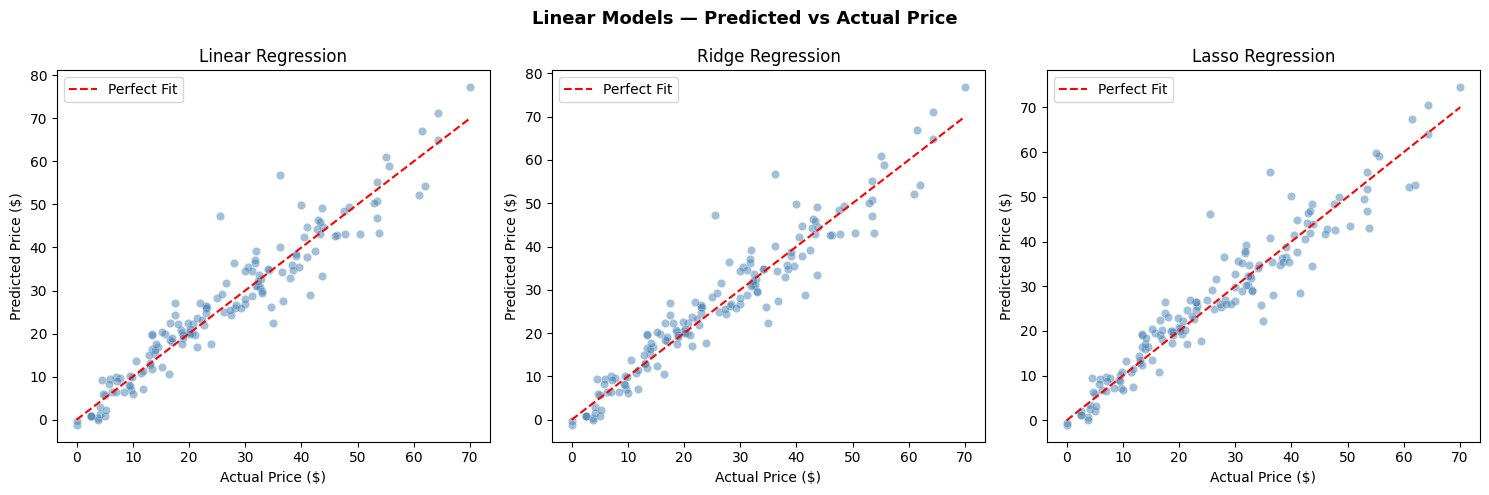

✅ plot_linear_models.png saved

✅ All 3 missing files regenerated!


In [23]:
# ============================================================
# REGENERATE 3 MISSING FILES
# ============================================================

# --- Resave Linear Regression model ---
joblib.dump(lr, "model_linear_regression.pkl")
print("✅ model_linear_regression.pkl saved")

# --- Resave Scaler ---
joblib.dump(scaler, "scaler.pkl")
print("✅ scaler.pkl saved")

# --- Regenerate linear models plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Linear Models — Predicted vs Actual Price",
             fontsize=13, fontweight='bold')

for ax, y_pred, name in zip(
    axes,
    [y_pred_lr, y_pred_ridge, y_pred_lasso],
    ["Linear", "Ridge", "Lasso"]
):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue',
               edgecolors='white', linewidth=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel("Actual Price ($)")
    ax.set_ylabel("Predicted Price ($)")
    ax.set_title(f"{name} Regression")
    ax.legend()

plt.tight_layout()
plt.savefig("plot_linear_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ plot_linear_models.png saved")

print("\n✅ All 3 missing files regenerated!")

In [25]:
# ============================================================
# BONUS — NEURAL NETWORK HYPERPARAMETER TUNING
# ============================================================
import itertools

# Define hyperparameter grid
hidden_sizes  = [64, 128, 256]
learning_rates = [0.001, 0.01, 0.05]
dropout_rates  = [0.0, 0.2]

# Store results
tuning_results = []

class MLPTunable(nn.Module):
    def __init__(self, input_dim, hidden_size, dropout_rate):
        super(MLPTunable, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 1)
        )
    def forward(self, x):
        return self.network(x)

total_combos = len(hidden_sizes) * len(learning_rates) * len(dropout_rates)
print(f"Testing {total_combos} combinations...\n")

for hidden_size, lr_val, dropout in itertools.product(
        hidden_sizes, learning_rates, dropout_rates):

    torch.manual_seed(42)
    model_t = MLPTunable(input_dim=14,
                         hidden_size=hidden_size,
                         dropout_rate=dropout)
    optimizer_t = torch.optim.Adam(model_t.parameters(), lr=lr_val)
    criterion_t = nn.MSELoss()

    # Train for 60 epochs (faster than full 100)
    for epoch in range(60):
        model_t.train()
        for X_batch, y_batch in train_loader:
            optimizer_t.zero_grad()
            loss = criterion_t(model_t(X_batch), y_batch)
            loss.backward()
            optimizer_t.step()

    # Evaluate
    model_t.eval()
    with torch.no_grad():
        y_pred_t = model_t(X_test_t).numpy().flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
    r2   = r2_score(y_test, y_pred_t)
    mae  = mean_absolute_error(y_test, y_pred_t)

    tuning_results.append({
        'hidden_size'  : hidden_size,
        'learning_rate': lr_val,
        'dropout_rate' : dropout,
        'RMSE'         : round(rmse, 4),
        'R2'           : round(r2,   4),
        'MAE'          : round(mae,  4)
    })
    print(f"  hidden={hidden_size:3d} | lr={lr_val:.3f} | "
          f"dropout={dropout} | RMSE={rmse:.4f} | R²={r2:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values('RMSE')
print("\n🏆 Top 5 Configurations:")
print(tuning_df.head().to_string(index=False))

Testing 18 combinations...

  hidden= 64 | lr=0.001 | dropout=0.0 | RMSE=5.2690 | R²=0.8920
  hidden= 64 | lr=0.001 | dropout=0.2 | RMSE=5.4860 | R²=0.8829
  hidden= 64 | lr=0.010 | dropout=0.0 | RMSE=5.6661 | R²=0.8751
  hidden= 64 | lr=0.010 | dropout=0.2 | RMSE=5.4757 | R²=0.8833
  hidden= 64 | lr=0.050 | dropout=0.0 | RMSE=6.6964 | R²=0.8255
  hidden= 64 | lr=0.050 | dropout=0.2 | RMSE=6.0968 | R²=0.8554
  hidden=128 | lr=0.001 | dropout=0.0 | RMSE=5.0977 | R²=0.8989
  hidden=128 | lr=0.001 | dropout=0.2 | RMSE=5.1723 | R²=0.8959
  hidden=128 | lr=0.010 | dropout=0.0 | RMSE=6.0447 | R²=0.8578
  hidden=128 | lr=0.010 | dropout=0.2 | RMSE=5.5180 | R²=0.8815
  hidden=128 | lr=0.050 | dropout=0.0 | RMSE=5.8336 | R²=0.8676
  hidden=128 | lr=0.050 | dropout=0.2 | RMSE=7.6432 | R²=0.7727
  hidden=256 | lr=0.001 | dropout=0.0 | RMSE=5.1390 | R²=0.8973
  hidden=256 | lr=0.001 | dropout=0.2 | RMSE=5.0400 | R²=0.9012
  hidden=256 | lr=0.010 | dropout=0.0 | RMSE=5.6198 | R²=0.8771
  hidden=256

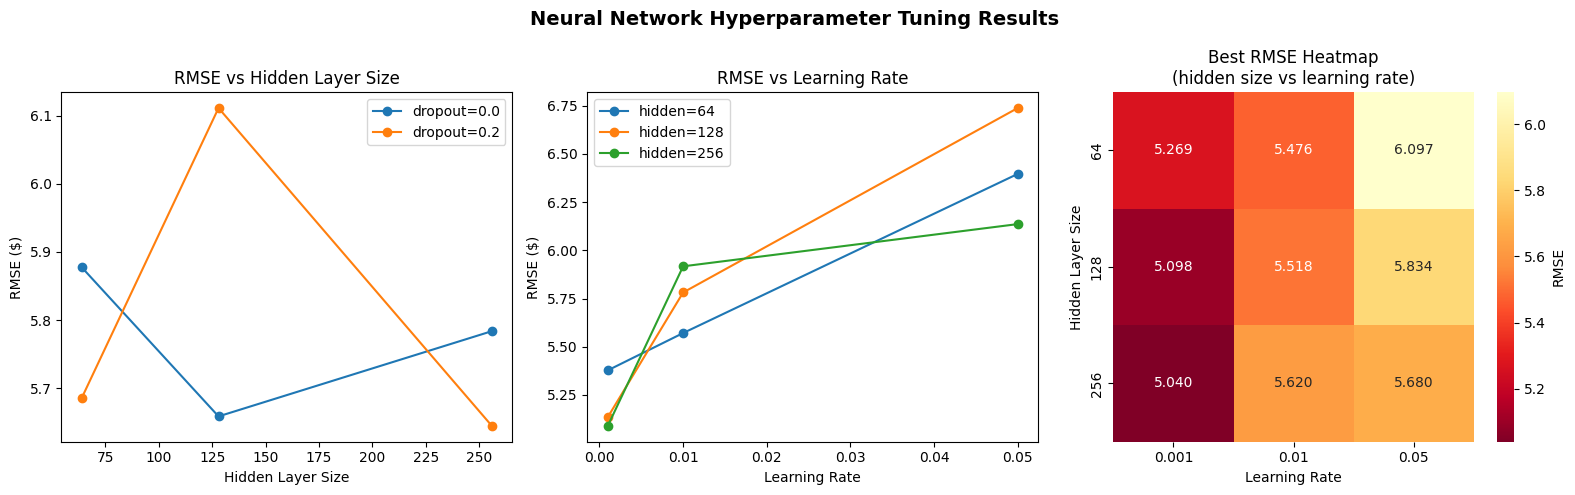


🏆 Best Configuration:
  Hidden Size   : 256
  Learning Rate : 0.001
  Dropout Rate  : 0.2
  RMSE          : $5.0400
  R²            : 0.9012

✅ Bonus: MLP tuning done. Results saved.


In [26]:
# --- Visualization of Tuning Results ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Neural Network Hyperparameter Tuning Results",
             fontsize=14, fontweight='bold')

# Plot 1: RMSE by hidden size
for dropout in dropout_rates:
    subset = tuning_df[tuning_df['dropout_rate'] == dropout]
    grouped = subset.groupby('hidden_size')['RMSE'].mean()
    axes[0].plot(grouped.index, grouped.values,
                 marker='o', label=f'dropout={dropout}')
axes[0].set_xlabel("Hidden Layer Size")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_title("RMSE vs Hidden Layer Size")
axes[0].legend()

# Plot 2: RMSE by learning rate
for hidden in hidden_sizes:
    subset = tuning_df[tuning_df['hidden_size'] == hidden]
    grouped = subset.groupby('learning_rate')['RMSE'].mean()
    axes[1].plot(grouped.index, grouped.values,
                 marker='o', label=f'hidden={hidden}')
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("RMSE ($)")
axes[1].set_title("RMSE vs Learning Rate")
axes[1].legend()

# Plot 3: Heatmap of best RMSE per hidden_size x learning_rate
pivot = tuning_df.groupby(
    ['hidden_size','learning_rate'])['RMSE'].min().unstack()
sns.heatmap(pivot, annot=True, fmt=".3f",
            cmap="YlOrRd_r", ax=axes[2],
            cbar_kws={"label": "RMSE"})
axes[2].set_title("Best RMSE Heatmap\n(hidden size vs learning rate)")
axes[2].set_xlabel("Learning Rate")
axes[2].set_ylabel("Hidden Layer Size")

plt.tight_layout()
plt.savefig("plot_mlp_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

# Save best tuned model
best_config = tuning_df.iloc[0]
print(f"\n🏆 Best Configuration:")
print(f"  Hidden Size   : {int(best_config['hidden_size'])}")
print(f"  Learning Rate : {best_config['learning_rate']}")
print(f"  Dropout Rate  : {best_config['dropout_rate']}")
print(f"  RMSE          : ${best_config['RMSE']:.4f}")
print(f"  R²            : {best_config['R2']:.4f}")

tuning_df.to_csv("mlp_tuning_results.csv", index=False)
print("\n✅ Bonus: MLP tuning done. Results saved.")